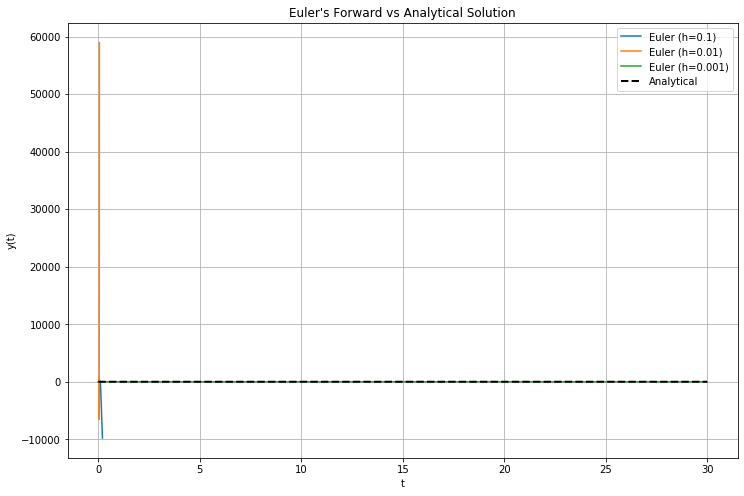

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ODE and Analytical Solution
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def analytical_sol(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# Parameters
t_start, t_end = 0, 30
y0 = 0
h_values = [.0000001, 0.00001, 0.001, .01, .1]

plt.figure(figsize=(12, 8))

# Solve for each h
for h in h_values:
    t_vals = np.arange(t_start, t_end + h, h)
    y_euler = np.zeros(len(t_vals))
    y_euler[0] = y0
    
    # Forward Euler Loop: y_{n+1} = y_n + h * f(t_n, y_n)
    for i in range(len(t_vals) - 1):
        y_euler[i+1] = y_euler[i] + h * f(t_vals[i], y_euler[i])
        
        # Stability Check: Avoid overflow for unstable h (like h=0.1)
        if abs(y_euler[i+1]) > 1e5: 
            y_euler[i+1:] = np.nan
            break
            
    plt.plot(t_vals, y_euler, label=f'Euler (h={h})')

# Plot Analytical Solution
t_fine = np.linspace(t_start, t_end, 1000)
plt.plot(t_fine, analytical_sol(t_fine), 'k--', label='Analytical', linewidth=2)

plt.title("Euler's Forward vs Analytical Solution")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()
